In [42]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import torch
from tqdm.auto import tqdm
import torch.nn.functional as F

import os
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from lib.cea_lib.signal1D import*
from lib.cea_lib.general import*
from lib.cea_lib.output import*
from lib.cea_lib.data_loader import*


# Conditional Diffusion Model on 1D Wavelet Coefficients

Dans ce notebook, le signal 1D $x_0 \in \mathbb{R}^{32}$ est décomposé en ondelettes de Haar au niveau 1 :
$$x_0 \longmapsto (Ca, Ch).$$

L'objectif n'est plus de conditionner la diffusion par un label discret. On utilise directement l'approximation basse fréquence `Ca` comme condition, et le modèle de diffusion apprend à générer le détail haute fréquence `Ch` :
$$p_\theta(Ch \mid Ca).$$

Cela correspond à une factorisation coarse-to-fine : `Ca` fixe la structure basse fréquence du signal, tandis que la diffusion modélise les composantes fines compatibles avec cette structure.


# Chargement du Dataset RT-CEA

On charge un dataset 2D RT-CEA connu, puis on le prétraite en images `32 x 32`. Pour rester dans un modèle 1D, chaque ligne horizontale de chaque image prétraitée est utilisée comme un signal de taille `SIGNAL_SIZE = 32`.

Les labels physiques chargés depuis le fichier HDF5 sont conservés uniquement comme métadonnées éventuelles. Ils ne sont pas utilisés par le modèle : le conditionnement de la diffusion reste `Ca`, et la variable diffusée reste `Ch`.


In [43]:
N = 50000
SIGNAL_SIZE = 32
DATA_FILE = "../data/RTCEA_bimode.hdf5"

MODEL_DIR = Path("saved_models")
MODEL_DIR.mkdir(exist_ok=True)
FORCE_RETRAIN = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Nombre minimal d'images 32x32 nécessaires si chaque ligne devient un signal 1D.
image_number = N // SIGNAL_SIZE

data_raw, labels_raw = load_RTCEA(DATA_FILE)

try:
    data_norm, metadata_labels = data_preprocessing(
        data_raw,
        labels_raw,
        resize=SIGNAL_SIZE,
    )
except ImportError as exc:
    # Fallback si OpenCV n'est pas disponible : crop/mask avec data_preprocessing,
    # puis resize par interpolation PyTorch.
    if "OpenCV" not in str(exc):
        raise
    data_cropped, metadata_labels = data_preprocessing(
        data_raw,
        labels_raw,
        resize=-1,
    )
    data_tensor = torch.as_tensor(data_cropped, dtype=torch.float32)[:, None]
    data_norm = torch.nn.functional.interpolate(
        data_tensor,
        size=(SIGNAL_SIZE, SIGNAL_SIZE),
        mode="bilinear",
        align_corners=False,
    )[:, 0].numpy()

if data_norm.shape[0] == 0:
    raise ValueError("data_preprocessing n'a retourné aucune image. Vérifier le fichier et les critères de crop.")

# Chaque image (32, 32) fournit 32 signaux 1D de longueur 32.
# On limite à N signaux après aplatissement en lignes.
profile_images = data_norm[:image_number]
profiles = profile_images.reshape(-1, SIGNAL_SIZE)[:N]

# Normalisation globale du dataset 1D pour une échelle compatible avec la diffusion gaussienne.
dataset = torch.as_tensor(profiles, dtype=torch.float32)
signal_mean = dataset.mean()
signal_std = dataset.std().clamp_min(1e-8)
dataset = (dataset - signal_mean) / signal_std

grid = torch.linspace(0, 1, SIGNAL_SIZE)
N = dataset.shape[0]

print("data_raw.shape       =", data_raw.shape)
print("data_norm.shape      =", data_norm.shape)
print("profile_images.shape =", profile_images.shape)
print("dataset.shape        =", dataset.shape)
print("mean/std             =", dataset.mean().item(), dataset.std().item())


data_raw.shape       = (1978, 512, 256)
data_norm.shape      = (1445, 32, 32)
profile_images.shape = (1445, 32, 32)
dataset.shape        = torch.Size([46240, 32])
mean/std             = -3.3659095066695954e-08 1.0


In [44]:
# Optionnel : pour changer le type de profil 1D, remplacer l'extraction par lignes ci-dessus
# par des colonnes, une moyenne verticale, ou une coupe choisie physiquement.


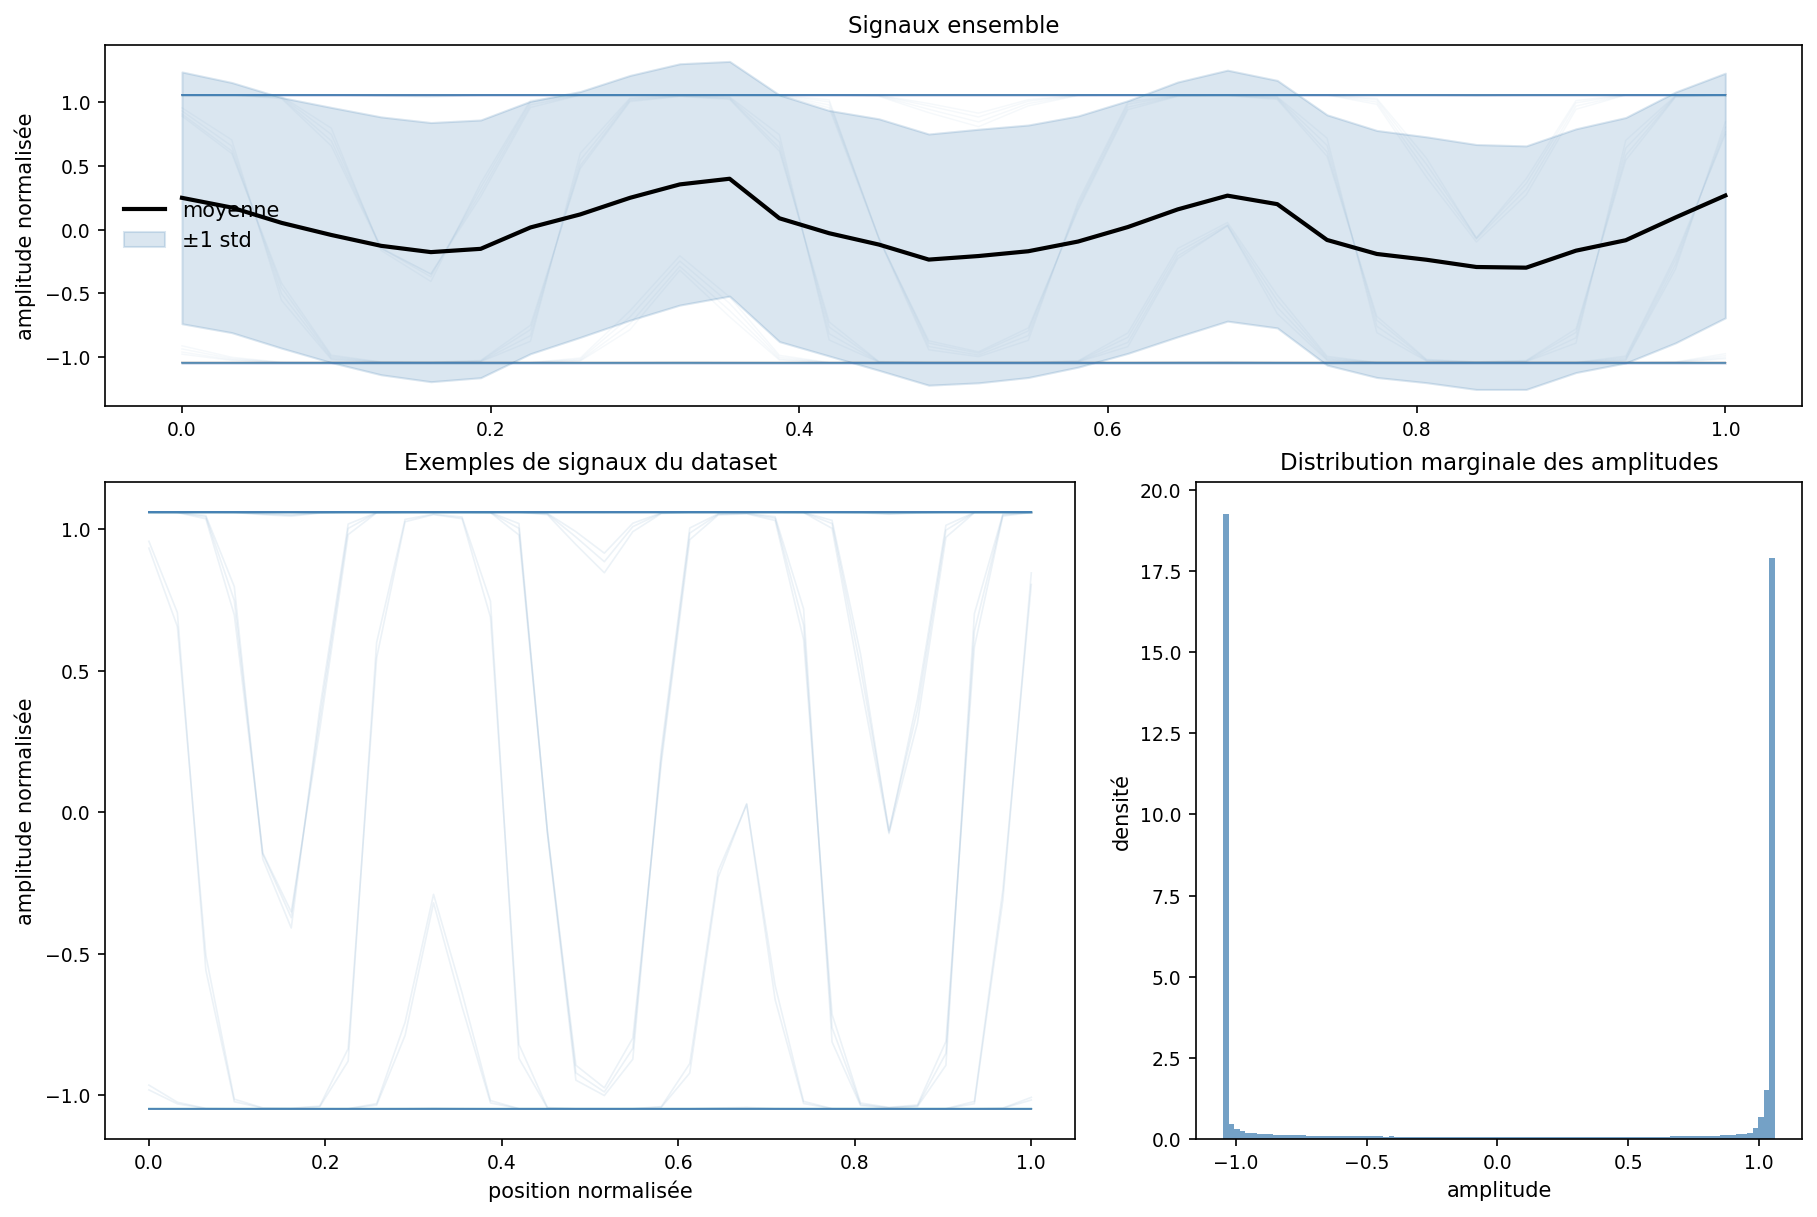

In [45]:
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[1.1, 1.0, 1.0],
    width_ratios=[1.6, 1.0],
)

ax_all = fig.add_subplot(gs[0, :])
ax_examples = fig.add_subplot(gs[1:, 0], sharex=ax_all)
ax_dist = fig.add_subplot(gs[1:, 1])

mean_signal = dataset.mean(dim=0)
std_signal = dataset.std(dim=0)

ax_all.plot(grid, dataset[:120].T, color="steelblue", alpha=0.05, linewidth=0.7)
ax_all.plot(grid, mean_signal, color="black", linewidth=2, label="moyenne")
ax_all.fill_between(
    grid.numpy(),
    (mean_signal - std_signal).numpy(),
    (mean_signal + std_signal).numpy(),
    color="steelblue",
    alpha=0.2,
    label="±1 std",
)
ax_all.set_title("Signaux ensemble")
ax_all.set_ylabel("amplitude normalisée")
ax_all.legend(frameon=False)

ax_examples.plot(grid, dataset[:80].T, color="steelblue", alpha=0.10, linewidth=0.8)
ax_examples.set_title("Exemples de signaux du dataset")
ax_examples.set_xlabel("position normalisée")
ax_examples.set_ylabel("amplitude normalisée")

ax_dist.hist(dataset.flatten(), bins=100, density=True, color="steelblue", alpha=0.75)
ax_dist.set_title("Distribution marginale des amplitudes")
ax_dist.set_xlabel("amplitude")
ax_dist.set_ylabel("densité")

plt.show()


## Décomposition ondelette multi-échelle 1D

On utilise une factorisation hiérarchique Haar à trois niveaux. Pour un signal de taille 32 :

$$x \rightarrow (Ca_1, Ch_1), \quad Ca_1 \rightarrow (Ca_2, Ch_2), \quad Ca_2 \rightarrow (Ca_3, Ch_3).$$

Le modèle génératif devient :

$$p(Ca_3)\,p(Ch_3\mid Ca_3)\,p(Ch_2\mid Ca_2)\,p(Ch_1\mid Ca_1),$$

avec $Ca_2 = W^{-1}(Ca_3, Ch_3)$ et $Ca_1 = W^{-1}(Ca_2, Ch_2)$. Cela évite de conditionner directement tous les détails sur le signal complet : chaque modèle ne voit que l'approximation basse fréquence à son échelle.

In [46]:
import pywt
from torch.utils.data import TensorDataset, DataLoader

WAVELET = "db1"
LEVELS = 3


def wavedec_tensor(signals, wavelet=WAVELET, level=LEVELS):
    """Retourne les coefficients PyWavelets [cA_level, cD_level, ..., cD1] sous forme de tenseurs."""
    if isinstance(signals, torch.Tensor):
        signals_np = signals.detach().cpu().numpy()
        dtype = signals.dtype
    else:
        signals_np = np.asarray(signals)
        dtype = torch.float32

    coeffs_per_sample = [pywt.wavedec(signal, wavelet=wavelet, level=level) for signal in signals_np]
    coeff_blocks = []
    for block_id in range(level + 1):
        coeff_blocks.append(torch.tensor(
            np.stack([sample[block_id] for sample in coeffs_per_sample], axis=0),
            dtype=dtype,
        ))
    return coeff_blocks


def waverec_tensor(coeff_blocks, wavelet=WAVELET, length=None):
    """Reconstruction complète depuis [cA_level, cD_level, ..., cD1]."""
    coeffs_np = [block.detach().cpu().numpy() if isinstance(block, torch.Tensor) else np.asarray(block) for block in coeff_blocks]
    reconstructed = [pywt.waverec([block[i] for block in coeffs_np], wavelet=wavelet) for i in range(coeffs_np[0].shape[0])]
    out = torch.tensor(np.stack(reconstructed, axis=0), dtype=coeff_blocks[0].dtype)
    return out[:, :length] if length is not None else out


def idwt_pair(ca, ch, wavelet=WAVELET):
    """Reconstruction d'une approximation plus fine depuis une paire (Ca_j, Ch_j)."""
    ca_np = ca.detach().cpu().numpy() if isinstance(ca, torch.Tensor) else np.asarray(ca)
    ch_np = ch.detach().cpu().numpy() if isinstance(ch, torch.Tensor) else np.asarray(ch)
    reconstructed = [pywt.waverec([ca_np[i], ch_np[i]], wavelet=wavelet) for i in range(ca_np.shape[0])]
    return torch.tensor(np.stack(reconstructed, axis=0), dtype=ca.dtype if isinstance(ca, torch.Tensor) else torch.float32)


In [47]:
# Coefficients de référence aux trois niveaux.
# wavedec niveau 3 renvoie [Ca3, Ch3, Ch2, Ch1].
Ca3, Ch3, Ch2, Ch1 = wavedec_tensor(dataset, wavelet=WAVELET, level=LEVELS)
Ca3_mean = Ca3.mean(0, keepdim=True)
Ca3_std = Ca3.std(0, keepdim=True)

Ca3_train = (
    Ca3 - Ca3_mean
) / (
    Ca3_std + 1e-8
)

# Approximations intermédiaires reconstruites depuis la hiérarchie exacte.
Ca2 = idwt_pair(Ca3, Ch3, wavelet=WAVELET)
Ca1 = idwt_pair(Ca2, Ch2, wavelet=WAVELET)

reconstructed = waverec_tensor([Ca3, Ch3, Ch2, Ch1], wavelet=WAVELET, length=SIGNAL_SIZE)
reconstruction_error = torch.mean((reconstructed - dataset) ** 2).sqrt()

print("dataset.shape =", dataset.shape)
print("Ca3.shape     =", Ca3.shape, " # modèle non conditionné")
print("Ch3.shape     =", Ch3.shape, " # conditionné par Ca3")
print("Ca2.shape     =", Ca2.shape, " # reconstruction inverse de (Ca3, Ch3)")
print("Ch2.shape     =", Ch2.shape, " # conditionné par Ca2")
print("Ca1.shape     =", Ca1.shape, " # reconstruction inverse de (Ca2, Ch2)")
print("Ch1.shape     =", Ch1.shape, " # conditionné par Ca1")
print("RMSE reconstruction niveau 3 =", reconstruction_error.item())


dataset.shape = torch.Size([46240, 32])
Ca3.shape     = torch.Size([46240, 4])  # modèle non conditionné
Ch3.shape     = torch.Size([46240, 4])  # conditionné par Ca3
Ca2.shape     = torch.Size([46240, 8])  # reconstruction inverse de (Ca3, Ch3)
Ch2.shape     = torch.Size([46240, 8])  # conditionné par Ca2
Ca1.shape     = torch.Size([46240, 16])  # reconstruction inverse de (Ca2, Ch2)
Ch1.shape     = torch.Size([46240, 16])  # conditionné par Ca1
RMSE reconstruction niveau 3 = 1.300635972256714e-07


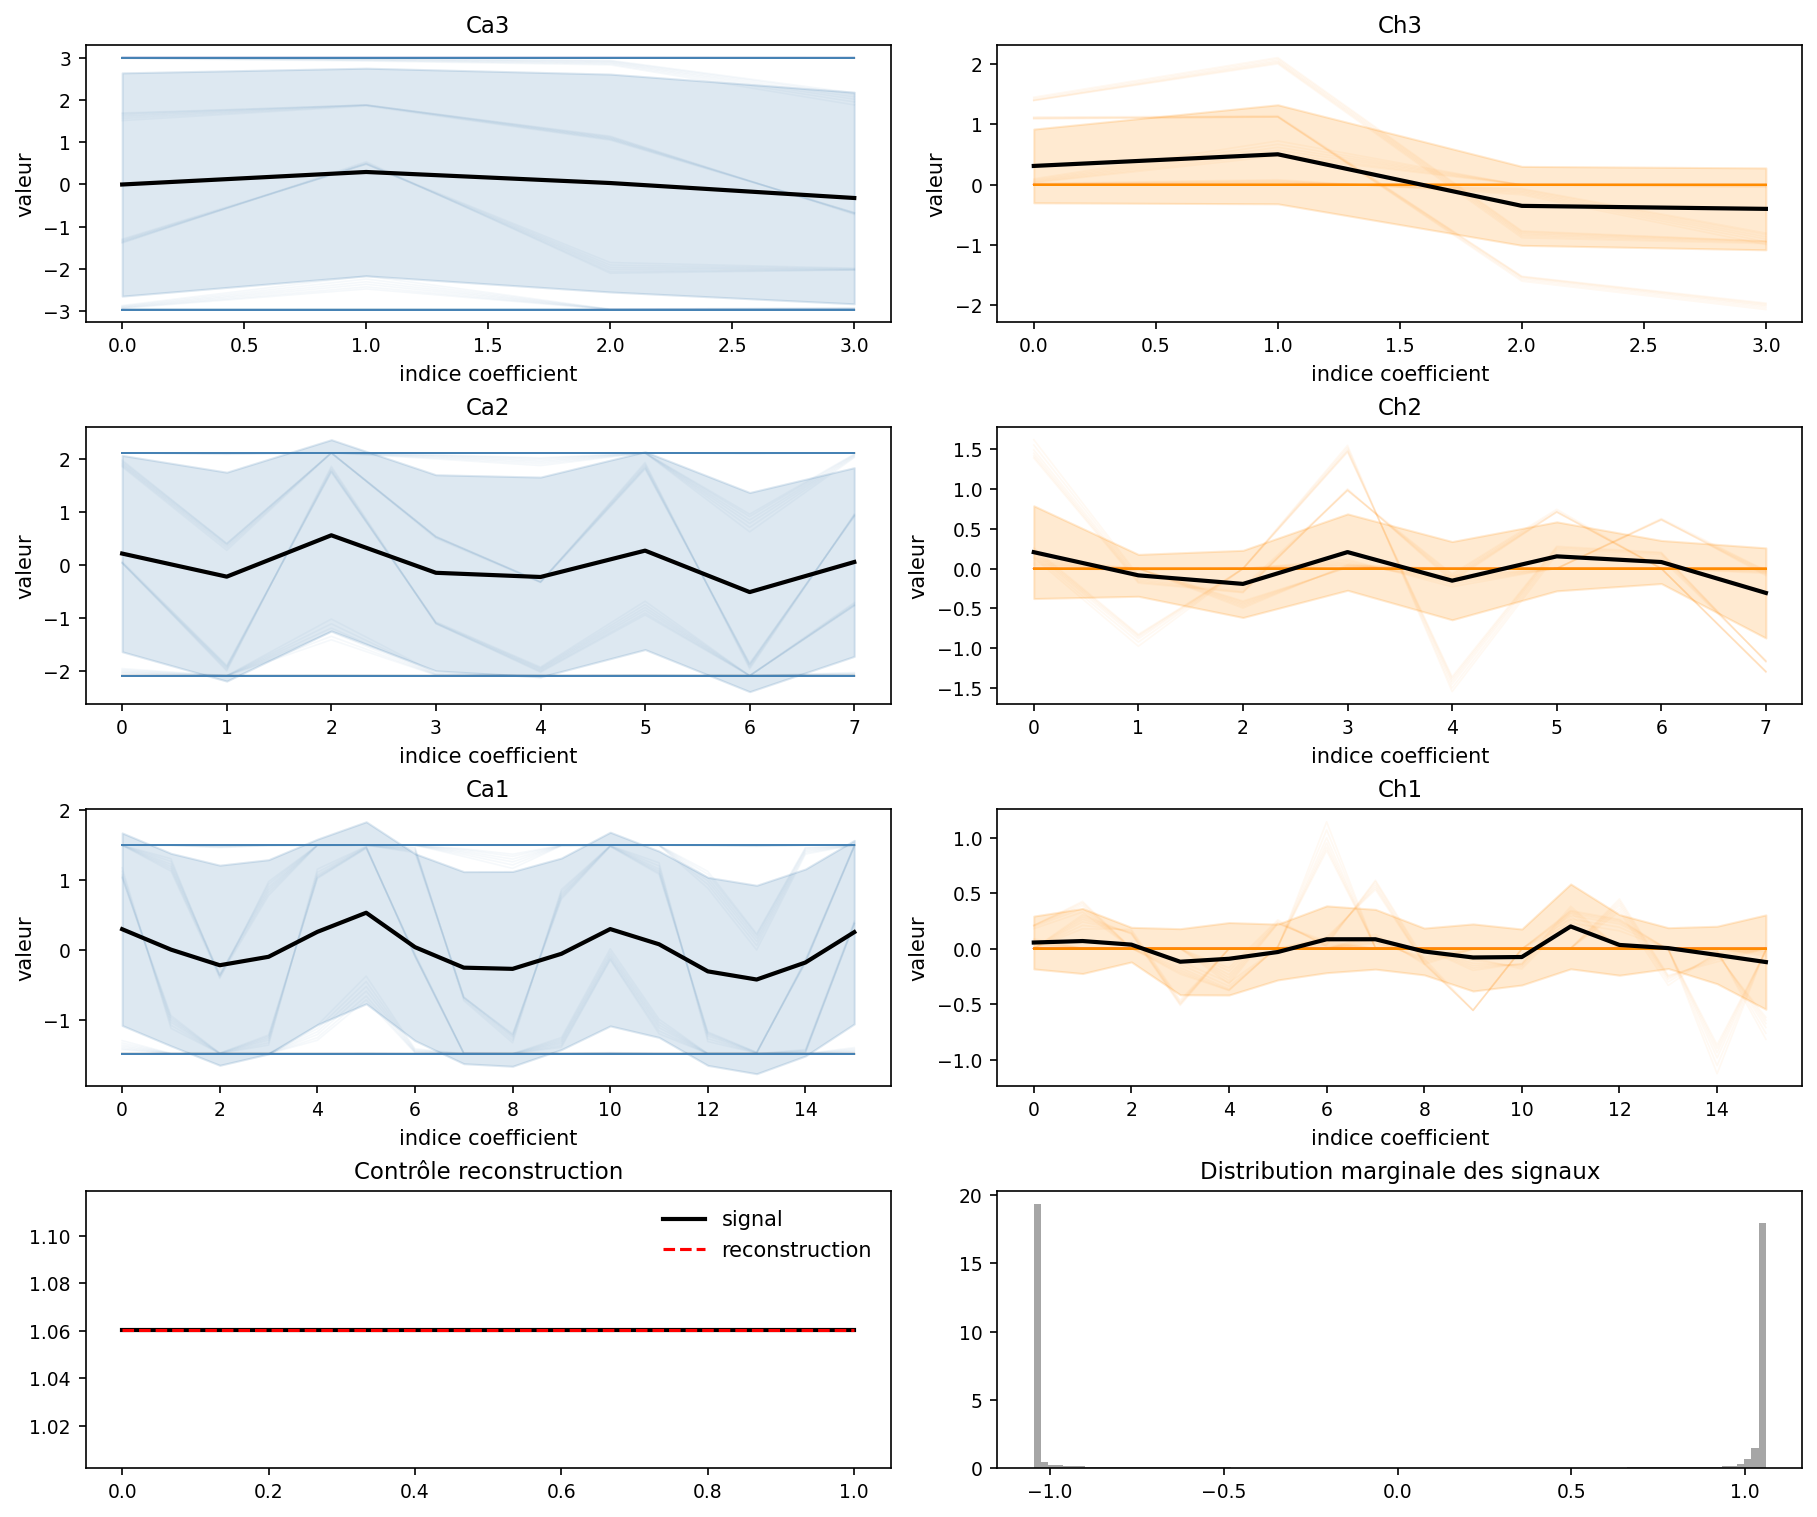

In [48]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10), constrained_layout=True)
blocks = [
    (Ca3, "Ca3", "steelblue"),
    (Ch3, "Ch3", "darkorange"),
    (Ca2, "Ca2", "steelblue"),
    (Ch2, "Ch2", "darkorange"),
    (Ca1, "Ca1", "steelblue"),
    (Ch1, "Ch1", "darkorange"),
]

for axis, (block, name, color) in zip(axes.flat[:6], blocks):
    coef_grid = torch.arange(block.shape[1])
    axis.plot(coef_grid, block[:200].T, color=color, alpha=0.05, linewidth=0.8)
    axis.plot(coef_grid, block.mean(dim=0), color="black", linewidth=2)
    axis.fill_between(
        coef_grid.numpy(),
        (block.mean(dim=0) - block.std(dim=0)).numpy(),
        (block.mean(dim=0) + block.std(dim=0)).numpy(),
        color=color,
        alpha=0.18,
    )
    axis.set_title(name)
    axis.set_xlabel("indice coefficient")
    axis.set_ylabel("valeur")

axes.flat[6].plot(grid, dataset[0], color="black", linewidth=2, label="signal")
axes.flat[6].plot(grid, reconstructed[0], color="red", linestyle="--", linewidth=1.5, label="reconstruction")
axes.flat[6].set_title("Contrôle reconstruction")
axes.flat[6].legend(frameon=False)
axes.flat[7].hist(dataset.flatten(), bins=100, density=True, color="gray", alpha=0.7)
axes.flat[7].set_title("Distribution marginale des signaux")
plt.show()


## Diffusion avant

Chaque variable de la cascade utilise le même processus DDPM scalaire par coefficient :

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon, \quad \epsilon\sim\mathcal{N}(0,I).$$

Le premier modèle apprend $p(Ca_3)$ sans condition. Les modèles suivants apprennent les distributions conditionnelles de détail.

In [49]:
# TIME_STEPS = 100
BETA = 0.02


def do_diffusion_until_snr(data, snr_threshold=3, beta=BETA):
    distributions, samples = [None], [data]
    xt = data
    alpha = 1.0 - beta
    alpha_bar = 1.0
    t = 0

    while True:
        q = torch.distributions.Normal(np.sqrt(alpha) * xt, np.sqrt(beta))
        xt = q.sample()
        distributions.append(q)
        samples.append(xt)
        t += 1
        alpha_bar *= alpha
        snr = alpha_bar / (1.0 - alpha_bar)
        if snr < snr_threshold:
            break

    return distributions, samples, t


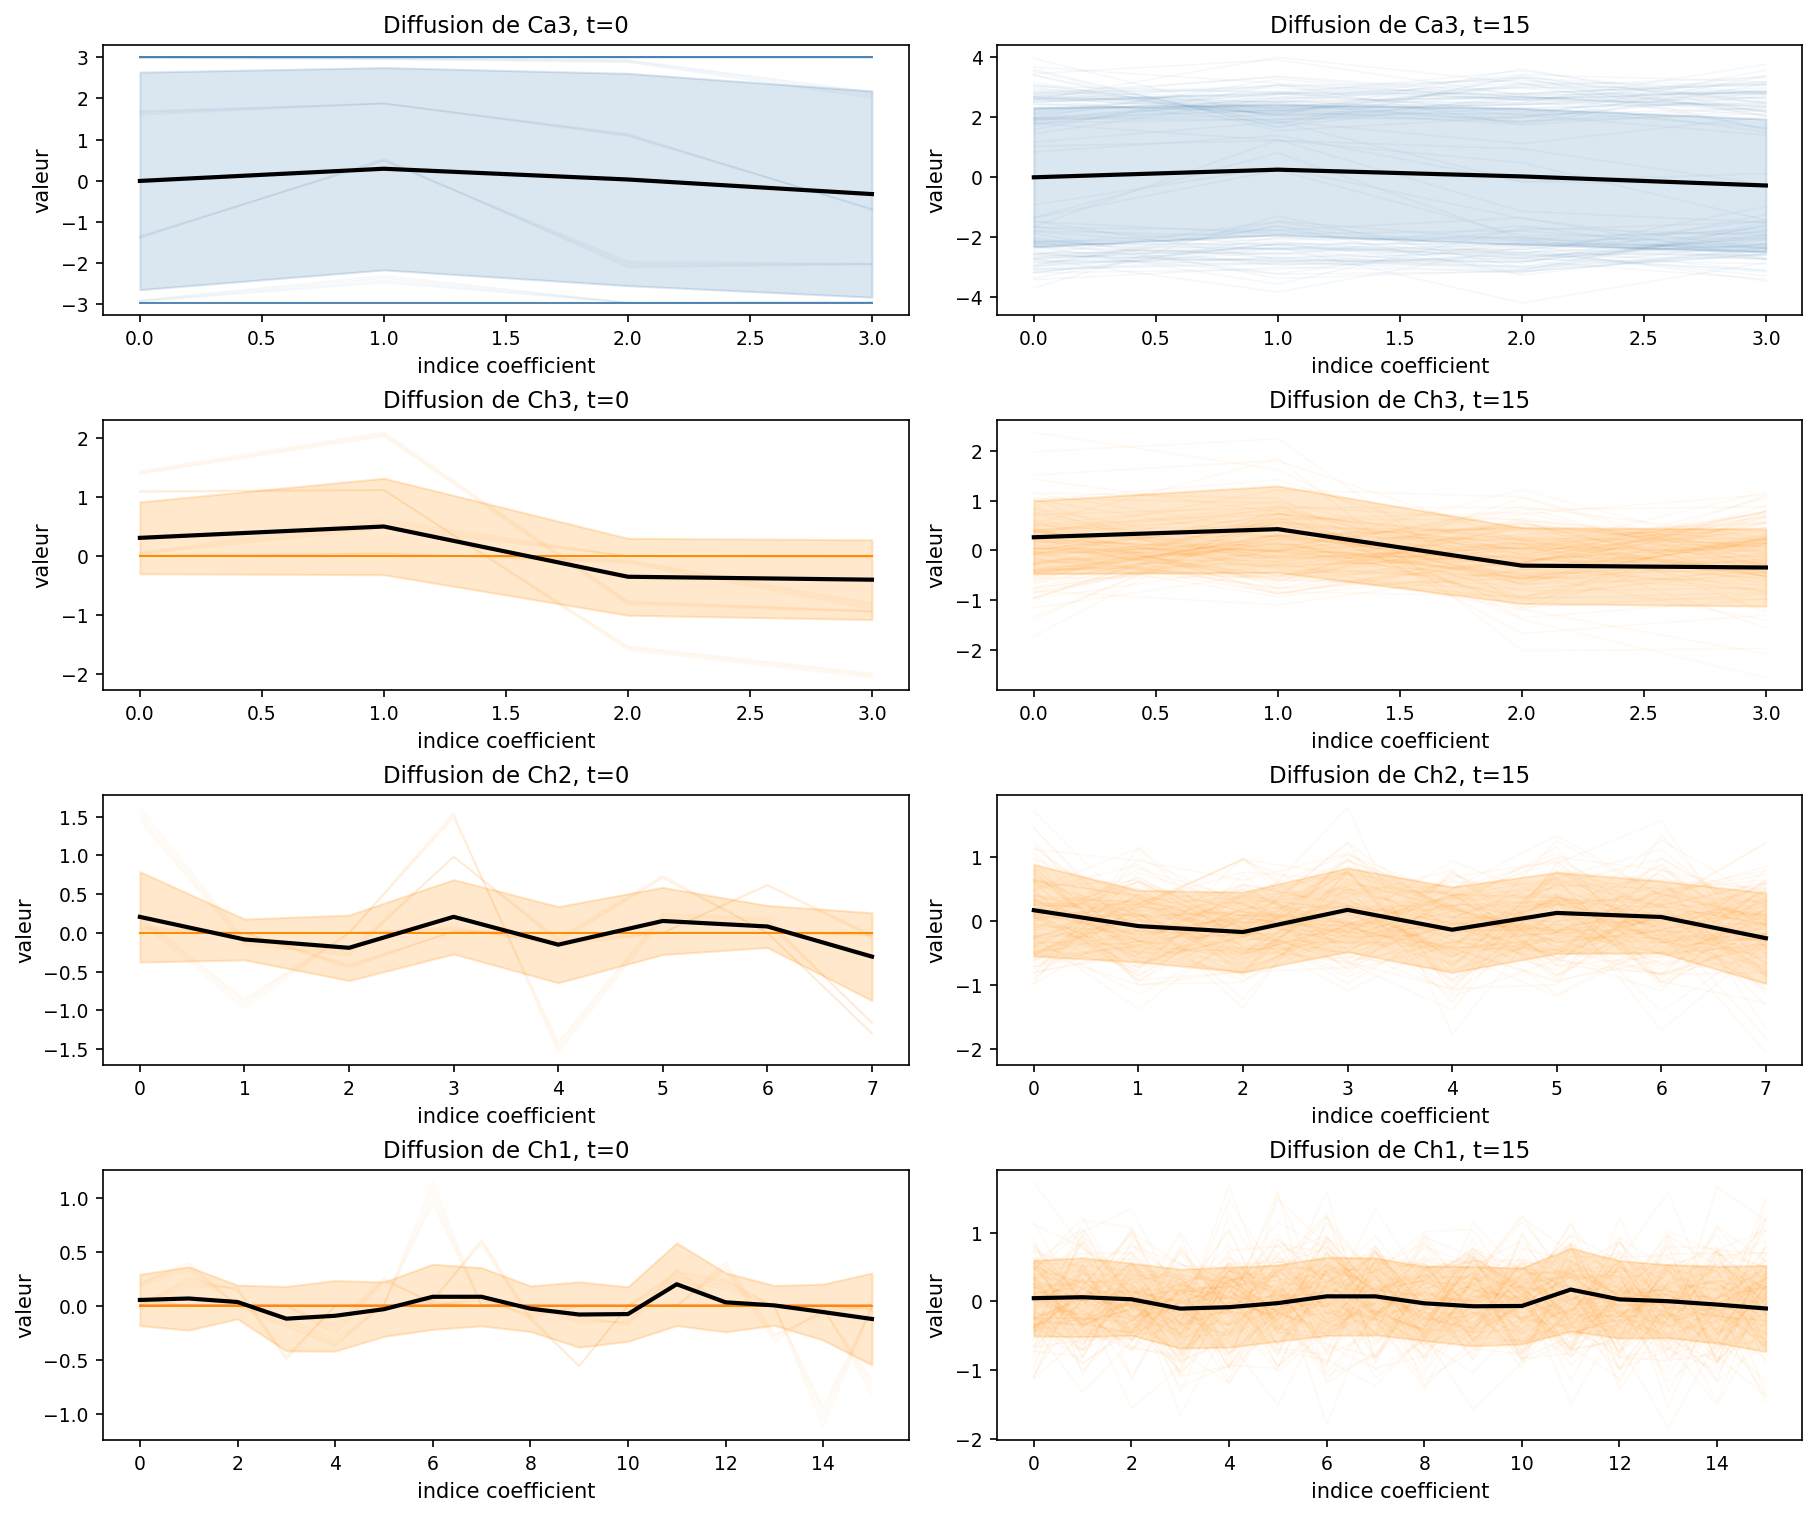

In [50]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10), constrained_layout=True)
for row, (block, name, color) in enumerate([
    (Ca3, "Ca3", "steelblue"),
    (Ch3, "Ch3", "darkorange"),
    (Ch2, "Ch2", "darkorange"),
    (Ch1, "Ch1", "darkorange"),
]):
    _, samples, T = do_diffusion_until_snr(block, snr_threshold=3, beta=BETA)
    samples_tensor = torch.stack(samples)
    coef_grid = torch.arange(block.shape[1])
    for col, time_index in enumerate([0, T]):
        subset = samples_tensor[time_index]
        mean_signal = subset.mean(dim=0)
        std_signal = subset.std(dim=0)
        axes[row, col].plot(coef_grid, subset[:120].T, color=color, alpha=0.05, linewidth=0.8)
        axes[row, col].plot(coef_grid, mean_signal, color="black", linewidth=2)
        axes[row, col].fill_between(
            coef_grid.numpy(),
            (mean_signal - std_signal).numpy(),
            (mean_signal + std_signal).numpy(),
            color=color,
            alpha=0.2,
        )
        axes[row, col].set_title(f"Diffusion de {name}, t={time_index}")
        axes[row, col].set_xlabel("indice coefficient")
        axes[row, col].set_ylabel("valeur")

plt.show()


# Entraînement de la cascade

On entraîne quatre estimateurs de bruit indépendants :

- `eps_model_Ca3` : non conditionné, cible `Ca3` ;
- `eps_model_Ch3` : cible `Ch3`, condition `Ca3` ;
- `eps_model_Ch2` : cible `Ch2`, condition `Ca2` ;
- `eps_model_Ch1` : cible `Ch1`, condition `Ca1`.

La condition utilisée pendant l'entraînement est l'approximation exacte de l'échelle correspondante. Pendant la génération, elle est remplacée par l'approximation générée récursivement, ce qui expose la cascade à une accumulation d'erreur non modélisée explicitement ici.

In [55]:
from pathlib import Path
import torch

def make_eps_model(target_dim, condition_dim=0, hidden_dim=128):
    time_dim = 3
    input_dim = (
        target_dim
        + time_dim
        + condition_dim
    )
    
    return torch.nn.Sequential(
        torch.nn.Linear(input_dim, hidden_dim),
        torch.nn.SiLU(),
        torch.nn.Linear(hidden_dim, hidden_dim),
        torch.nn.SiLU(),
        torch.nn.Linear(hidden_dim, hidden_dim),
        torch.nn.SiLU(),
        torch.nn.Linear(hidden_dim, target_dim),
    )


def comupte_features(xt, t, T, condition=None):
    t_norm = t / T
    features = [xt, t_norm, torch.sin(np.pi * t_norm), torch.cos(np.pi * t_norm)]
    if condition is not None:
        features.append(condition.to(device=xt.device, dtype=xt.dtype))
    return torch.cat(features, dim=1)


def compute_loss(x0, condition, model, T):
    batch_size = x0.shape[0]
    t = torch.randint(1, T + 1, (batch_size, 1), device=x0.device, dtype=x0.dtype)
    alpha_bar = (1 - BETA) ** t
    eps = torch.randn_like(x0)
    xt = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * eps

    features = comupte_features(xt, t, T, condition)
    eps_pred = model(features)
    return F.mse_loss(eps_pred, eps)


def compute_loss_x0(x0, model, T):

    batch_size = x0.shape[0]

    t = torch.randint(
        1,
        T + 1,
        (batch_size, 1),
        device=x0.device,
        dtype=x0.dtype,
    )

    alpha_bar = (1 - BETA) ** t

    eps = torch.randn_like(x0)

    xt = (
        torch.sqrt(alpha_bar) * x0
        + torch.sqrt(1 - alpha_bar) * eps
    )

    features = comupte_features(xt, t, T)

    x0_pred = model(features)

    return F.mse_loss(
        x0_pred,
        x0,
    )


def train_diffusion_model(name, target, T, condition=None, epochs=500, batch_size=256, lr=1e-3):
    model_path = MODEL_DIR / f"{name}_diffusion_model.pt"

    target_dim = target.shape[1]
    condition_dim = 0 if condition is None else condition.shape[1]


    # Chargement si modèle déjà entraîné
    # --------------------------------------------------
    if model_path.exists() and not FORCE_RETRAIN:
        print(f"Chargement : {model_path}")

        model = make_eps_model(
            target_dim,
            condition_dim=condition_dim,
        ).to(DEVICE)

        checkpoint = torch.load(
            model_path,
            map_location=DEVICE,
        )

        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        loss_history = checkpoint.get(
            "loss_history",
            []
        )

        return model, loss_history


    print(f"Entraînement : {name}")
    
    if condition is None:
        hidden_dim = 512
    else:
        hidden_dim = 128
    model = make_eps_model(target_dim, condition_dim, hidden_dim).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-6)

    tensors = (target,) if condition is None else (target, condition)
    loader = DataLoader(TensorDataset(*tensors), batch_size=batch_size, shuffle=True)
    loss_history = []

    for epoch in range(epochs):
        pbar = tqdm(loader, desc=f"{name} epoch {epoch + 1}/{epochs}", leave=False)
        for batch in pbar:
            x_batch = batch[0].to(DEVICE)
            c_batch = (
                None
                if condition is None
                else batch[1].to(DEVICE)
            )

            optimizer.zero_grad()
            if condition is None:
                loss = compute_loss_x0(
                    x_batch,
                    model,
                    T
                )
            else:
                loss = compute_loss(
                    x_batch,
                    c_batch,
                    model,
                    T
                )
            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    # sauvegarde du modèle entraîné
    torch.save({
        "model_state_dict": model.state_dict(),
        "loss_history": loss_history,
    }, model_path)

    return model, loss_history


In [57]:
EPOCHS_NB = 75

models = {}
loss_histories = {}

models["Ca3"], loss_histories["Ca3"] = train_diffusion_model(
    "Ca3_non_conditionné",
    Ca3_train,
    T=T,
    condition=None,
    epochs=EPOCHS_NB,
)
models["Ch3"], loss_histories["Ch3"] = train_diffusion_model(
    "Ch3_Ca3",
    Ch3,
    T=T,
    condition=Ca3,
    epochs=EPOCHS_NB,
)
models["Ch2"], loss_histories["Ch2"] = train_diffusion_model(
    "Ch2_Ca2",
    Ch2,
    T=T,
    condition=Ca2,
    epochs=EPOCHS_NB,
)
models["Ch1"], loss_histories["Ch1"] = train_diffusion_model(
    "Ch1_Ca1",
    Ch1,
    T=T,
    condition=Ca1,
    epochs=EPOCHS_NB,
)


Entraînement : Ca3_non_conditionné


Entraînement : Ch3_Ca3


Entraînement : Ch2_Ca2


Entraînement : Ch1_Ca1


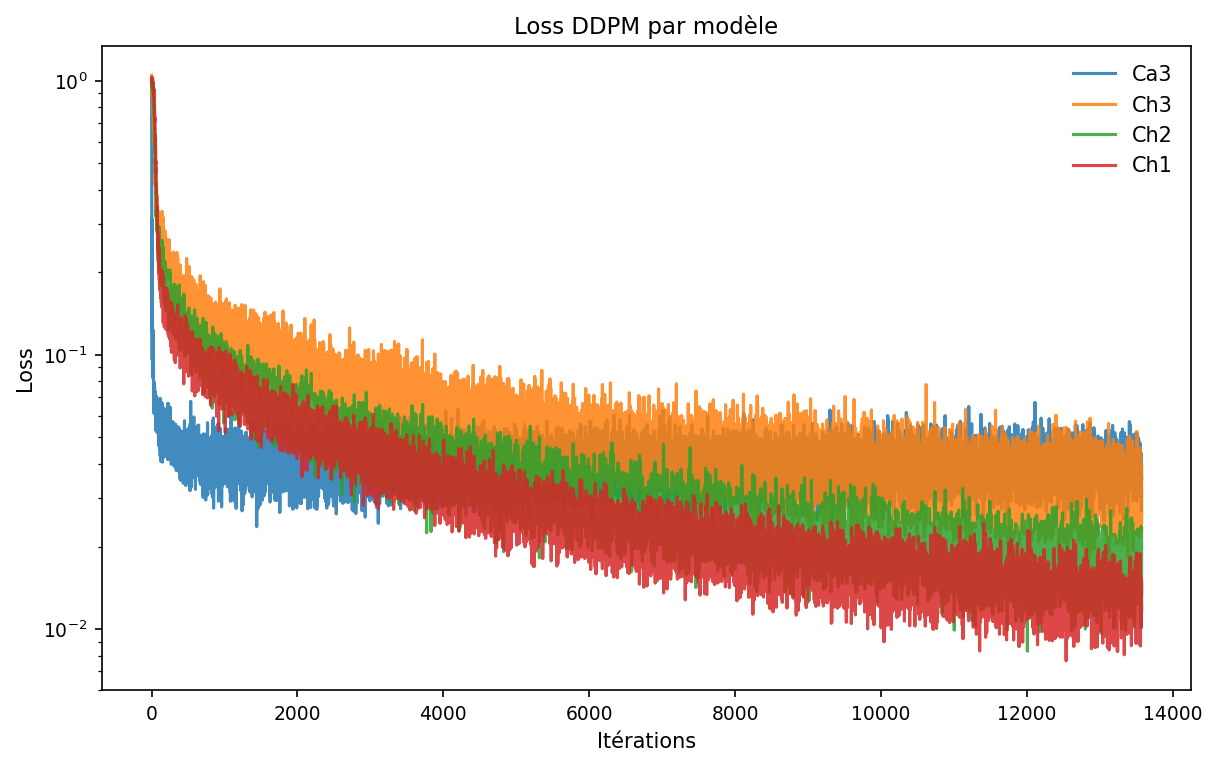

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5), constrained_layout=True)
for name, history in loss_histories.items():
    ax.plot(history, label=name, alpha=0.85)
ax.set_yscale("log")
ax.set_ylabel("Loss")
ax.set_xlabel("Itérations")
ax.set_title("Loss DDPM par modèle")
ax.legend(frameon=False)
plt.show()


# Génération hiérarchique et test

La génération suit exactement l'ordre demandé :

`Ca3` non conditionné → `Ch3 | Ca3` → reconstruction `Ca2` → `Ch2 | Ca2` → reconstruction `Ca1` → `Ch1 | Ca1` → reconstruction du signal.

In [ ]:
def sample_reverse(model, target_dim, steps, condition=None, count=None, beta=BETA):
    device = next(model.parameters()).device
    if condition is not None:
        condition = condition.to(device).float()
        count = condition.shape[0]
    elif count is None:
        raise ValueError("count doit être fourni pour un sampling non conditionné.")

    xt = torch.randn(count, target_dim, device=device)
    sample_history = [xt.detach().cpu()]

    for t in range(steps, 0, -1):
        t_norm = torch.full(
            (count, 1),
            t / steps,
            device=device
        )

        features = [
            xt,
            t_norm,
            torch.sin(torch.pi * t_norm),
            torch.cos(torch.pi * t_norm),
        ]

        if condition is not None:
            features.append(condition)

        eps_pred = model(
            torch.cat(features, dim=1)
        )
        alpha = 1 - beta
        alpha_bar = alpha ** t
        mean = (1 / np.sqrt(alpha)) * (xt - (beta / np.sqrt(1 - alpha_bar)) * eps_pred)

        if t > 1:
            xt = mean + np.sqrt(beta) * torch.randn_like(xt)
        else:
            xt = mean

        sample_history.append(xt.detach().cpu())

    return torch.stack(sample_history)

def sample_reverse_x0(
    model,
    target_dim,
    steps,
    count,
    beta=BETA,
):

    device = next(model.parameters()).device

    xt = torch.randn(
        count,
        target_dim,
        device=device,
    )

    sample_history = [
        xt.detach().cpu()
    ]

    alpha = 1.0 - beta

    for t in range(steps, 0, -1):

        t_norm = torch.full(
            (count, 1),
            t / steps,
            device=device,
        )

        features = torch.cat(
            [
                xt,
                t_norm,
                torch.sin(torch.pi * t_norm),
                torch.cos(torch.pi * t_norm),
            ],
            dim=1,
        )

        x0_pred = model(features)

        alpha_bar = alpha ** t

        eps_pred = (
            xt
            - torch.sqrt(torch.tensor(alpha_bar, device=device))
            * x0_pred
        ) / torch.sqrt(
            torch.tensor(
                1 - alpha_bar,
                device=device,
            )
        )

        mean = (
            xt
            - beta
            / np.sqrt(1 - alpha_bar)
            * eps_pred
        ) / np.sqrt(alpha)

        if t > 1:

            xt = (
                mean
                + np.sqrt(beta)
                * torch.randn_like(xt)
            )

        else:

            xt = mean

        sample_history.append(
            xt.detach().cpu()
        )

    return torch.stack(sample_history)

def sample_wavelet_cascade(models, count, steps):
    samples_ca3 = sample_reverse_x0(
        models["Ca3"],
        target_dim=Ca3.shape[1],
        steps=steps,
        count=count,
    )
    generated_ca3 = samples_ca3[-1]
    generated_ca3 = (
        generated_ca3
        * (Ca3_std + 1e-8)
        + Ca3_mean
    )

    samples_ch3 = sample_reverse(models["Ch3"], target_dim=Ch3.shape[1], steps=steps, condition=generated_ca3)
    generated_ch3 = samples_ch3[-1]
    generated_ca2 = idwt_pair(generated_ca3, generated_ch3, wavelet=WAVELET)

    samples_ch2 = sample_reverse(models["Ch2"], target_dim=Ch2.shape[1], steps=steps, condition=generated_ca2)
    generated_ch2 = samples_ch2[-1]
    generated_ca1 = idwt_pair(generated_ca2, generated_ch2, wavelet=WAVELET)

    samples_ch1 = sample_reverse(models["Ch1"], target_dim=Ch1.shape[1], steps=steps, condition=generated_ca1)
    generated_ch1 = samples_ch1[-1]

    generated_signals = idwt_pair(generated_ca1, generated_ch1, wavelet=WAVELET)[:, :SIGNAL_SIZE]

    return {
        "Ca3": generated_ca3,
        "Ch3": generated_ch3,
        "Ca2": generated_ca2,
        "Ch2": generated_ch2,
        "Ca1": generated_ca1,
        "Ch1": generated_ch1,
        "signals": generated_signals,
    }


In [66]:
num_generated = 5000
generated = sample_wavelet_cascade(models, count=num_generated, steps=T)
generated_signals = generated["signals"]
original_signals = dataset[:num_generated]

# Baselines de reconstruction exacte avec les coefficients réels tronqués au même nombre d'échantillons.
exact_reconstructed_signals = waverec_tensor(
    [Ca3[:num_generated], Ch3[:num_generated], Ch2[:num_generated], Ch1[:num_generated]],
    wavelet=WAVELET,
    length=SIGNAL_SIZE,
)

exact_rmse = torch.mean((exact_reconstructed_signals - original_signals.cpu()) ** 2).sqrt()
generated_distribution_rmse = torch.mean(
    (generated_signals.mean(dim=0) - original_signals.cpu().mean(dim=0)) ** 2
).sqrt()

print("Reconstruction inverse exacte RMSE                 =", exact_rmse.item())
print("RMSE des moyennes générée/originale               =", generated_distribution_rmse.item())
print("generated_signals.shape                           =", generated_signals.shape)


Reconstruction inverse exacte RMSE                 = 1.1433493085633017e-07
RMSE des moyennes générée/originale               = 0.32810842990875244
generated_signals.shape                           = torch.Size([5000, 32])


# Faux FID

Ici le FID n'est pas fait dans un espace latent car l'espace d'origine est suffisament petit donc c´est une sorte de faux FID.
$$
\mathrm{FID}
=
\left\|\mu_r - \mu_g\right\|_2^2
+
\mathrm{Tr}
\left(
\Sigma_r
+
\Sigma_g
-
2\left(\Sigma_r\Sigma_g\right)^{1/2}
\right)
$$

In [ ]:
from scipy.linalg import sqrtm
import numpy as np


def compute_fid(real, fake):

    real = real.detach().cpu().numpy()
    fake = fake.detach().cpu().numpy()

    mu_real = np.mean(real, axis=0)
    mu_fake = np.mean(fake, axis=0)

    sigma_real = np.cov(real, rowvar=False)
    sigma_fake = np.cov(fake, rowvar=False)

    diff = mu_real - mu_fake

    covmean = sqrtm(sigma_real @ sigma_fake)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = (
        diff @ diff
        + np.trace(
            sigma_real
            + sigma_fake
            - 2 * covmean
        )
    )

    return float(fid)

print("FID orinignal Ca3    :", compute_fid(Ca3, Ca3))
print("FID orinignal Ch3    :", compute_fid(Ch3, Ch3))
print("FID orinignal Ch2    :", compute_fid(Ch2, Ch2))
print("FID orinignal Ch1    :", compute_fid(Ch1, Ch1))
print("FID orinignal Signal :", compute_fid(dataset[:len(generated['signals'])], dataset[:len(generated['signals'])]))

print("=================")

print("FID Ca3    :", compute_fid(Ca3, generated["Ca3"]))
print("FID Ch3    :", compute_fid(Ch3, generated["Ch3"]))
print("FID Ch2    :", compute_fid(Ch2, generated["Ch2"]))
print("FID Ch1    :", compute_fid(Ch1, generated["Ch1"]))
print("FID Signal :", compute_fid(dataset[:len(generated['signals'])],
                                  generated["signals"]))

FID orinignal Ca3    : 7.815970093361102e-14
FID orinignal Ch3    : 4.3298697960381105e-15
FID orinignal Ch2    : 5.828670879282072e-16
FID orinignal Ch1    : -1.1934897514720433e-15
FID orinignal Signal : -2.194977533065412e-11
FID Ca3    : 15.194711988875714
FID Ch3    : 1.4746690136466638
FID Ch2    : 0.7671416634907975
FID Ch1    : 1.7307234611921078
FID Signal : 21.378693713001294


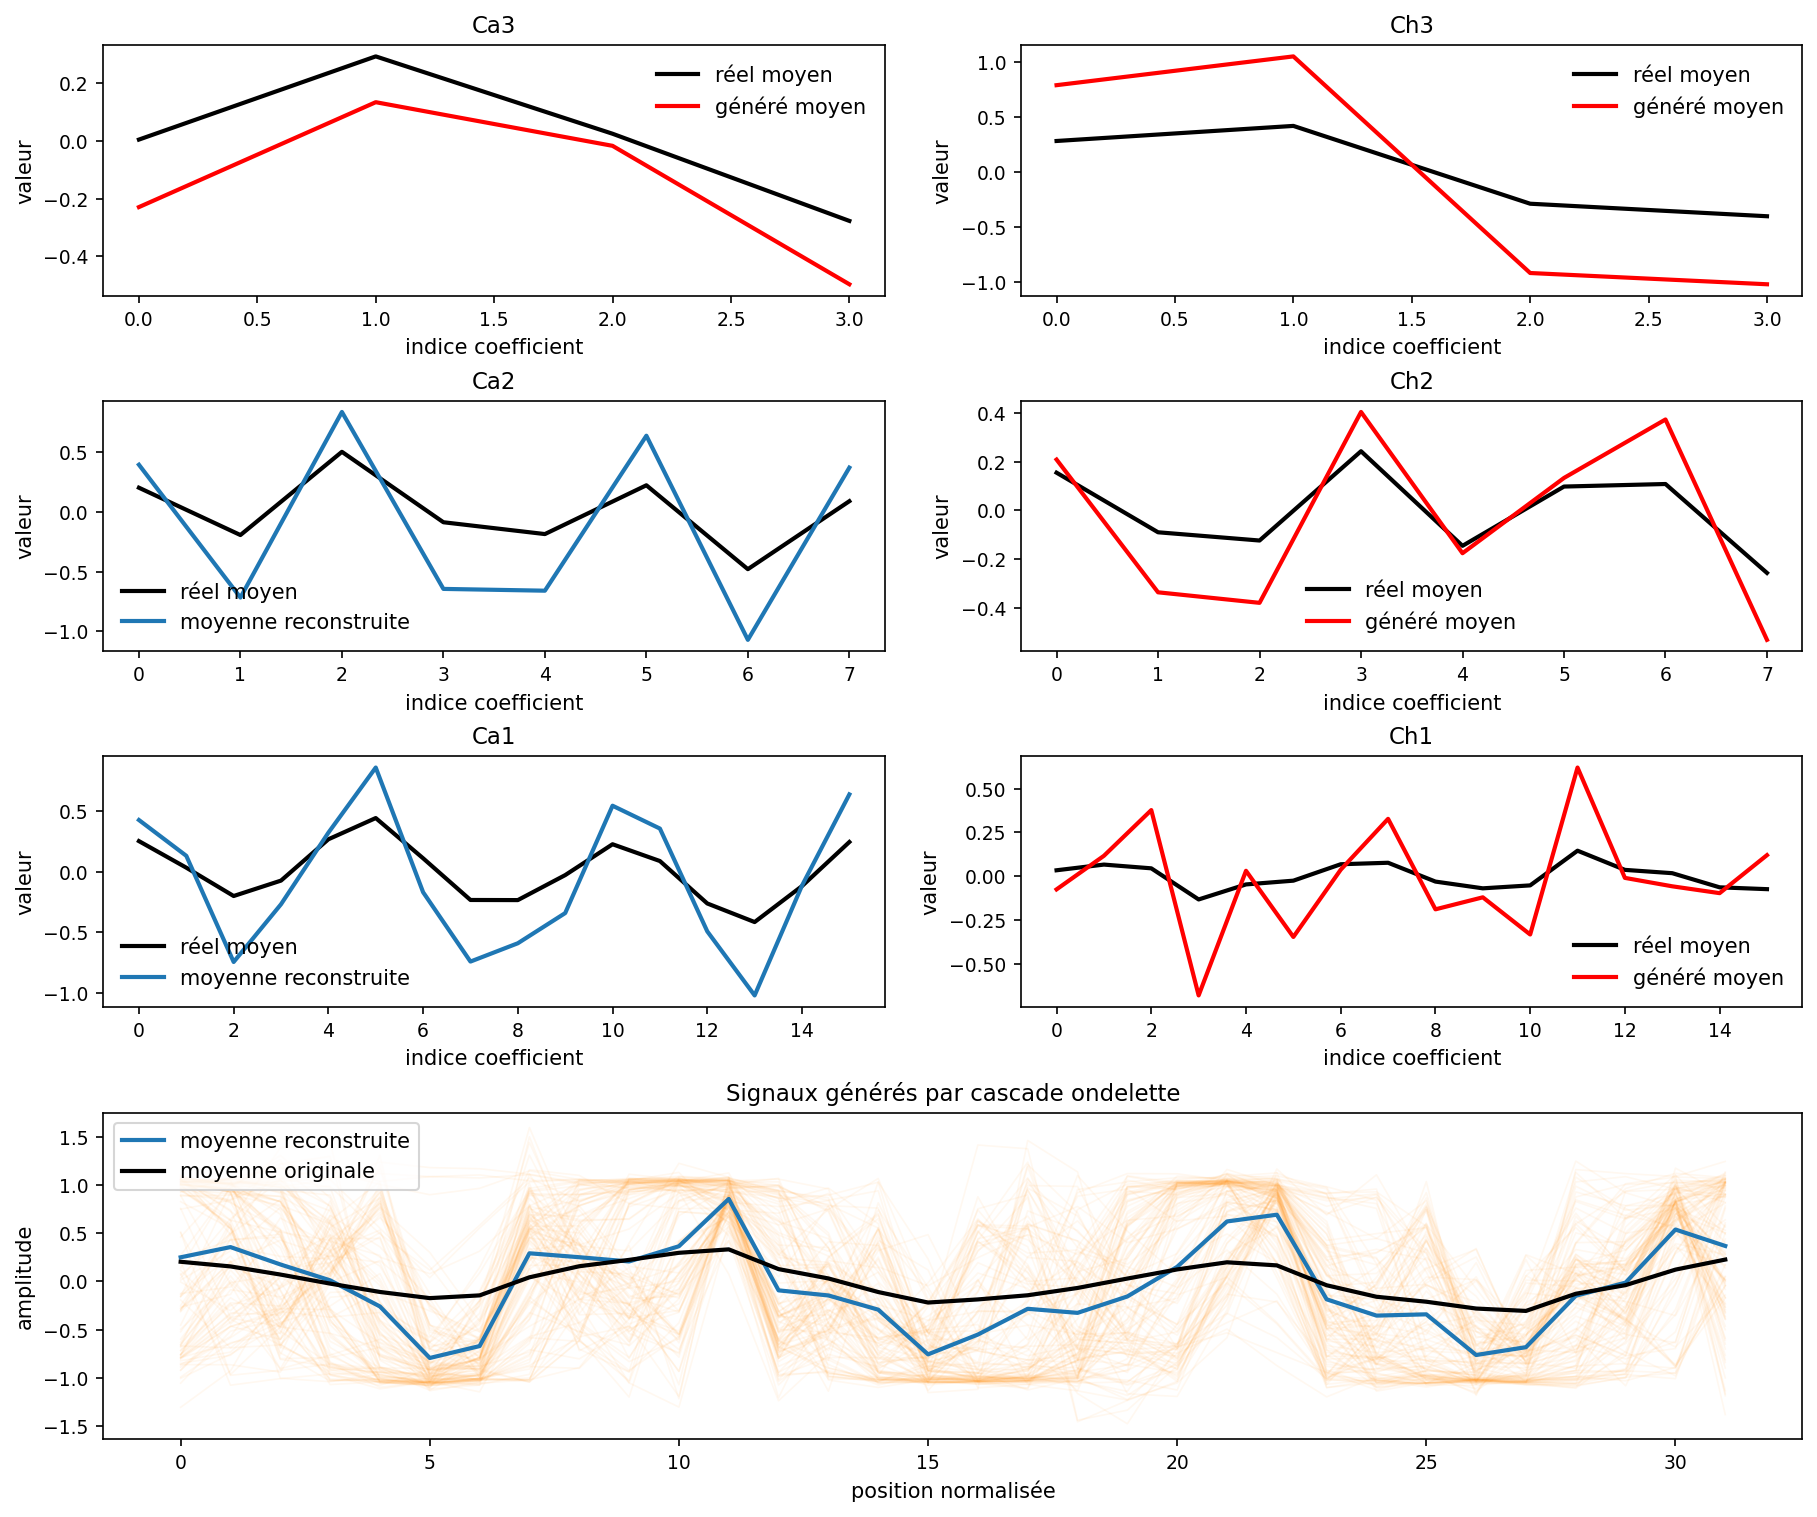

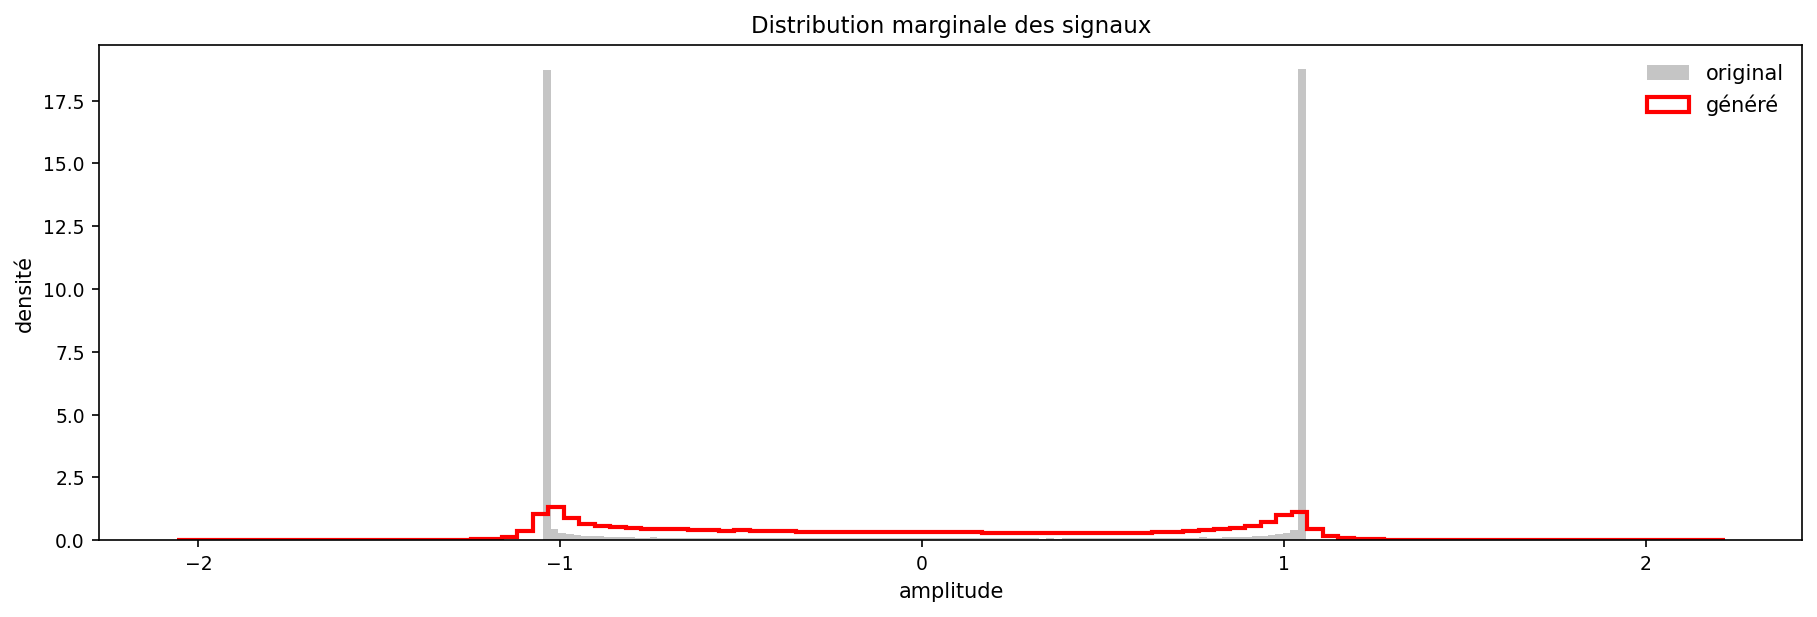

In [ ]:
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
})

fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = fig.add_gridspec(4, 2, height_ratios=[1.0, 1.0, 1.0, 1.3])

ax_all = fig.add_subplot(gs[3, :])
ax_blocks = [fig.add_subplot(gs[i, j]) for i in range(0, 3) for j in range(2)]

signal_grid = torch.arange(generated_signals.shape[1])
ax_all.plot(signal_grid, generated_signals[:120].T, color="darkorange", alpha=0.06, linewidth=0.8)
ax_all.plot(signal_grid, generated_signals.mean(dim=0), color="tab:blue", linewidth=2, label="moyenne reconstruite")
ax_all.plot(signal_grid, original_signals.mean(dim=0), color="black", linewidth=2, label="moyenne originale")
ax_all.set_title("Signaux générés par cascade ondelette")
ax_all.set_xlabel("position normalisée")
ax_all.set_ylabel("amplitude")
ax_all.legend(loc="upper left")

for axis, name, real_block in zip(
    ax_blocks,
    ["Ca3", "Ch3", "Ca2", "Ch2", "Ca1", "Ch1"],
    [Ca3, Ch3, Ca2, Ch2, Ca1, Ch1],
):
    fake_block = generated[name]
    coef_grid = torch.arange(real_block.shape[1])
    axis.plot(coef_grid, real_block[:num_generated].mean(dim=0), color="black", linewidth=2, label="réel moyen")
    if name in ["Ca2", "Ca1"]:
        color = "tab:blue"
        label = "moyenne reconstruite"
    else:
        color = "red"
        label = "généré moyen"

    axis.plot(coef_grid, fake_block.mean(dim=0), color=color, linewidth=2, label=label)
    axis.set_title(name)
    axis.set_xlabel("indice coefficient")
    axis.set_ylabel("valeur")
    axis.legend(frameon=False)

plt.savefig("500-epochs-generated_signals_and_coefficients.png", dpi=150)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 4), constrained_layout=True)
ax.hist(original_signals.flatten(), bins=100, density=True, color="gray", alpha=0.45, label="original")
ax.hist(generated_signals.flatten(), bins=100, density=True, histtype="step", linewidth=2, color="red", label="généré")
ax.set_title("Distribution marginale des signaux")
ax.set_xlabel("amplitude")
ax.set_ylabel("densité")
ax.legend(frameon=False)

plt.savefig("500-epochs-generated_signals_distribution.png", dpi=150)
plt.show()


# Attention - Fausse comparaison !

Comme le premier model qui estime $C_a$ n'est pas conditionnée les signaux génerés ne le sont pas non plus. Le plot suivant montre alors non pas un equivalent mais le plus proche voisin du jeux de base.

$$ x^*_{reel} = \arg \min_i||x_{generated} - x_i||_2 $$

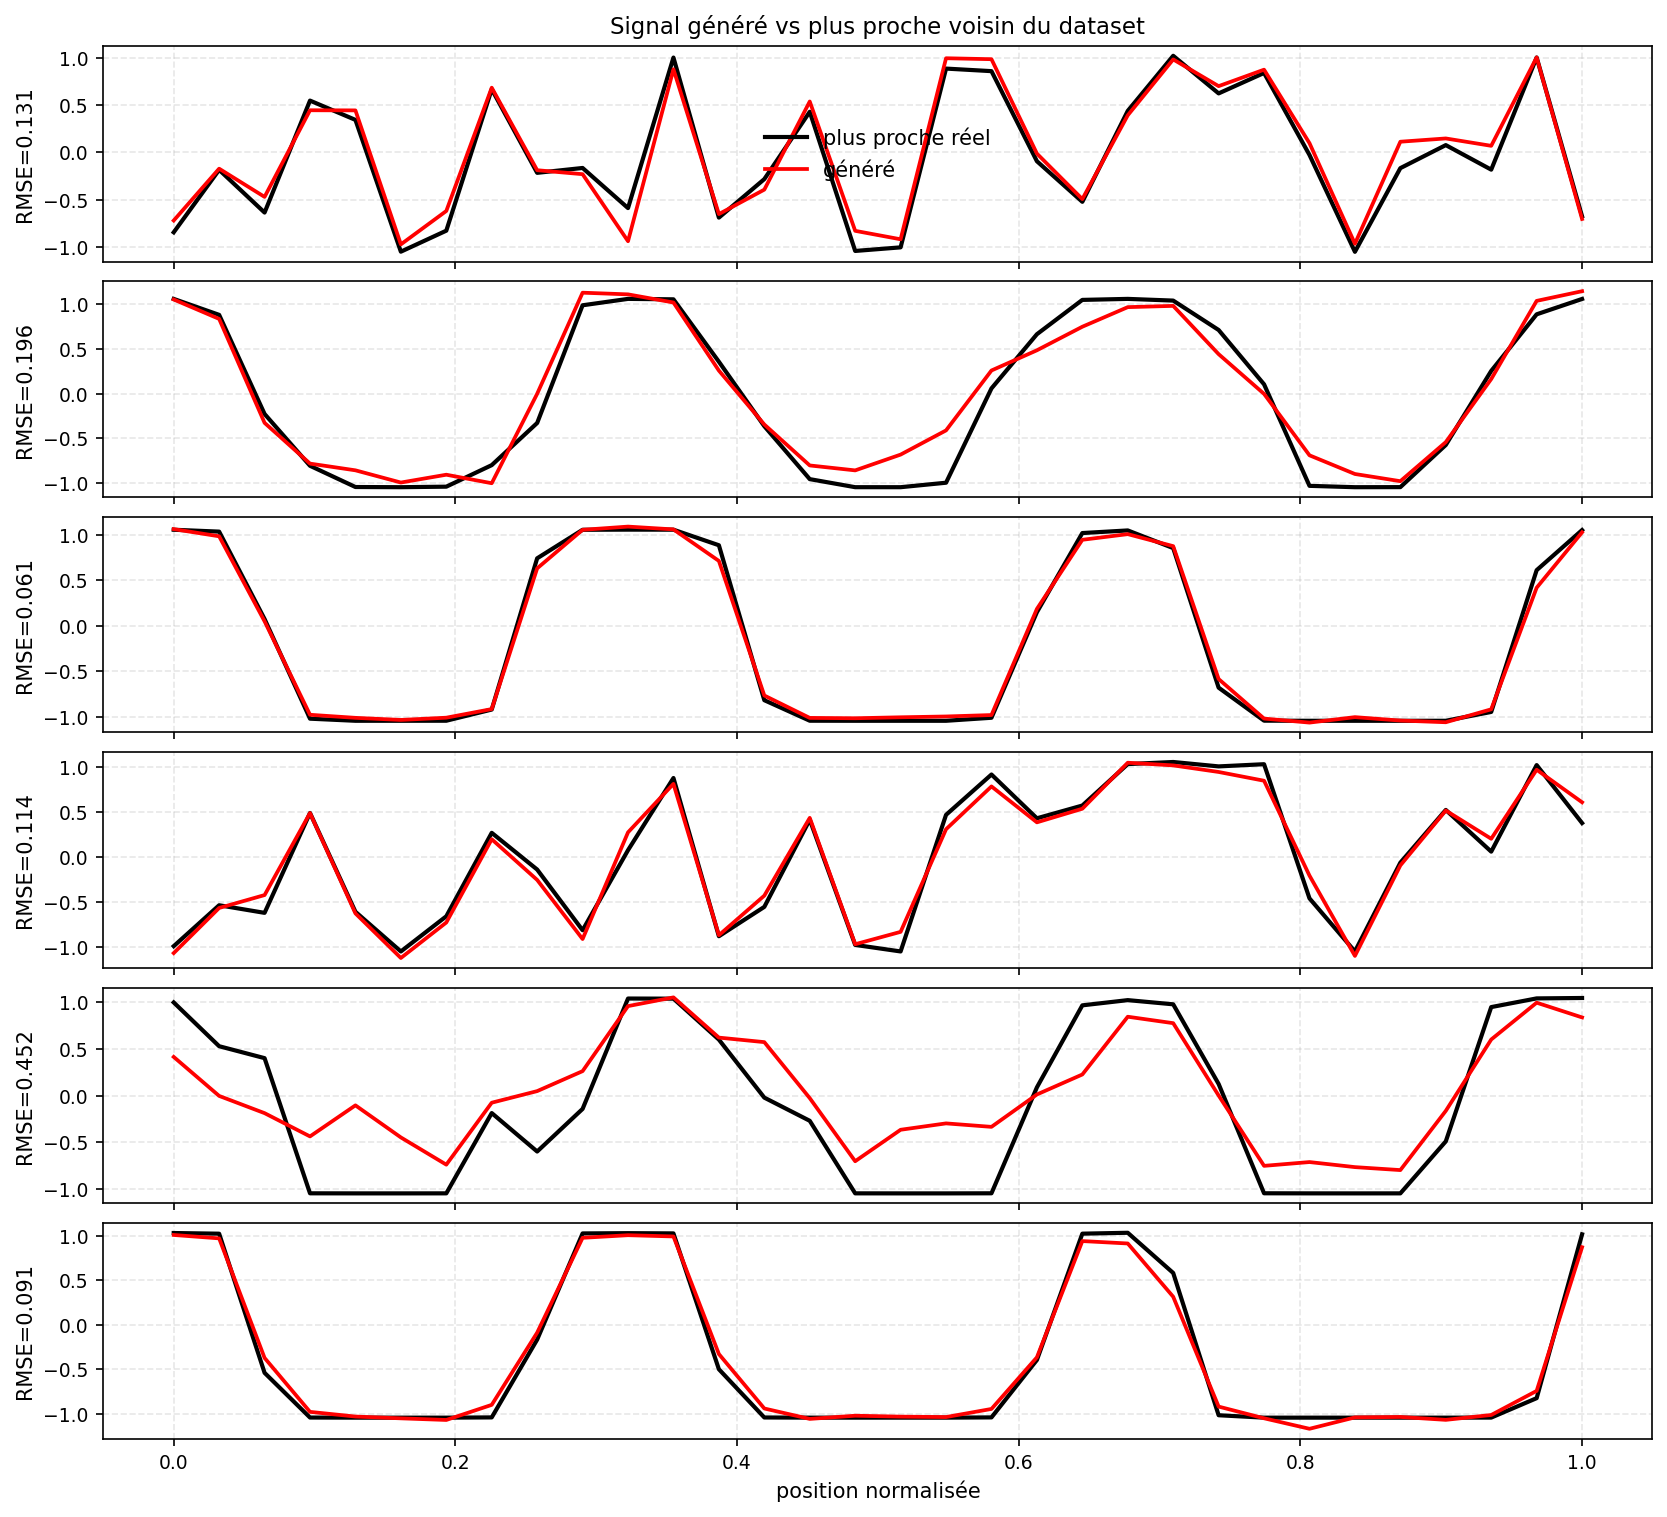

In [ ]:
def plot_nearest_neighbors(
    generated_signals,
    dataset,
    n_examples=6,
):
    example_ids = torch.linspace(
        0,
        len(generated_signals) - 1,
        n_examples,
    ).long()

    signal_grid = torch.linspace(
        0,
        1,
        generated_signals.shape[1],
    )

    fig, axes = plt.subplots(
        n_examples,
        1,
        figsize=(11, 10),
        sharex=True,
        constrained_layout=True,
    )

    if n_examples == 1:
        axes = [axes]

    for axis, idx in zip(axes, example_ids):
        idx = int(idx.item())

        generated = generated_signals[idx]

        distances = torch.mean(
            (dataset - generated[None, :])**2,
            dim=1,
        )

        nearest_idx = torch.argmin(distances)

        nearest_real = dataset[nearest_idx]

        rmse = torch.sqrt(
            distances[nearest_idx]
        )

        axis.plot(
            signal_grid,
            nearest_real,
            color="black",
            linewidth=2,
            label="plus proche réel",
        )

        axis.plot(
            signal_grid,
            generated,
            color="red",
            linewidth=1.8,
            label="généré",
        )

        axis.set_ylabel(
            f"RMSE={rmse:.3f}"
        )


        axis.grid(
            True,
            linestyle="--",
            alpha=0.3,
        )

    axes[0].set_title(
        "Signal généré vs plus proche voisin du dataset"
    )

    axes[0].legend(
        frameon=False,
    )

    axes[-1].set_xlabel(
        "position normalisée"
    )

    plt.show()

plot_nearest_neighbors(
    generated_signals,
    dataset,
)

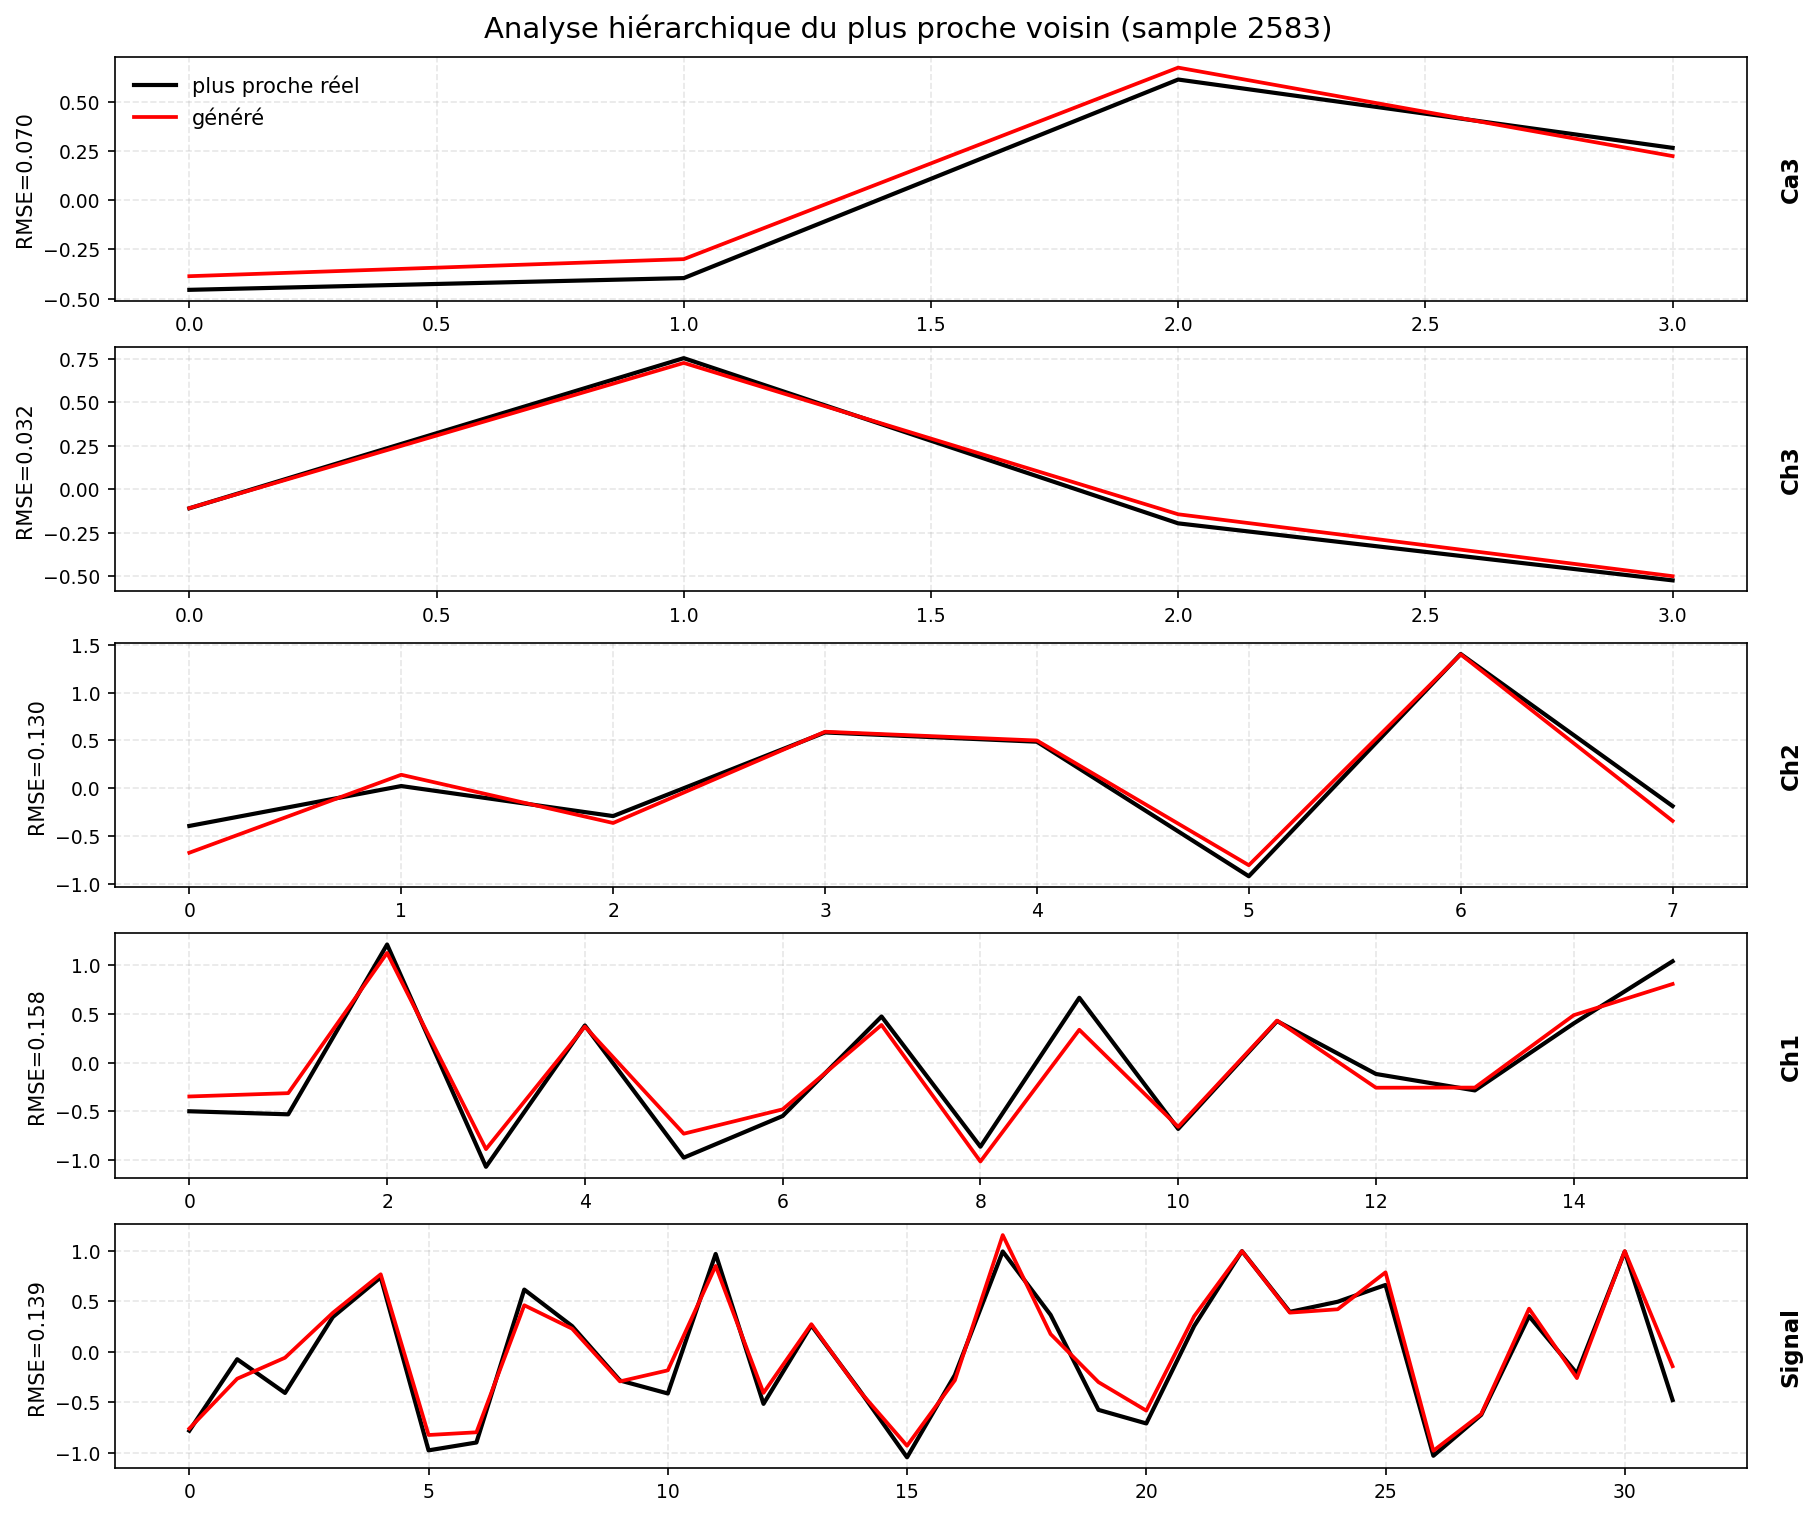

In [ ]:
def plot_hierarchy_nearest_neighbor(
    generated,
    dataset,
    Ca3,
    Ch3,
    Ch2,
    Ch1,
    sample_idx=0,
):
    levels = [
        ("Ca3", generated["Ca3"], Ca3),
        ("Ch3", generated["Ch3"], Ch3),
        ("Ch2", generated["Ch2"], Ch2),
        ("Ch1", generated["Ch1"], Ch1),
        ("Signal", generated["signals"], dataset),
    ]

    fig, axes = plt.subplots(
        len(levels),
        1,
        figsize=(12, 10),
        constrained_layout=True,
    )

    for axis, (name, generated_block, real_block) in zip(axes, levels):

        generated_sample = generated_block[sample_idx]

        distances = torch.mean(
            (real_block - generated_sample[None, :]) ** 2,
            dim=1,
        )

        nearest_idx = torch.argmin(distances)

        nearest_real = real_block[nearest_idx]

        rmse = torch.sqrt(distances[nearest_idx]).item()

        x = torch.arange(len(generated_sample))

        axis.plot(
            x,
            nearest_real,
            color="black",
            linewidth=2,
            label="plus proche réel",
        )

        axis.plot(
            x,
            generated_sample,
            color="red",
            linewidth=1.8,
            label="généré",
        )

        axis.set_ylabel(
            f"RMSE={rmse:.3f}"
        )

        axis.text(
            1.02,
            0.5,
            name,
            transform=axis.transAxes,
            rotation=90,
            va="center",
            ha="left",
            fontsize=11,
            fontweight="bold",
        )

        axis.grid(
            True,
            linestyle="--",
            alpha=0.3,
        )

    axes[0].legend(frameon=False)

    fig.suptitle(
        f"Analyse hiérarchique du plus proche voisin (sample {sample_idx})",
        fontsize=14,
    )

    plt.show()


rand_sample_idx = np.random.randint(0, generated_signals.shape[0])

plot_hierarchy_nearest_neighbor(
    generated,
    dataset,
    Ca3,
    Ch3,
    Ch2,
    Ch1,
    rand_sample_idx
)